# 🧬 ANCOM-BC Differential Abundance Analysis

In [1]:
# Import Libraries
from qiime2 import Artifact, Metadata
from qiime2.plugins import composition, feature_table
import biom
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import seaborn as sns

/home/nxwang/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/q2_assembly/_utils.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Load Inputs

In [2]:
#load ANCOM-BC inputs
BASE_DIR = "/ddn_scratch/miter/nph-tables"
#metagenomics (DNA)
metaG_pergenome_path = os.path.join(BASE_DIR, "metaG-pergenome-feature-table.qza")
#metadata
metadata_path = os.path.join(BASE_DIR, "nph_metadata.tsv")

In [3]:
# load QIIME2 artifacts / metadata
table = Artifact.load(metaG_pergenome_path)
md = Metadata.load(metadata_path)
metadata = md.to_dataframe()

In [4]:
ft_df = table.view(pd.DataFrame)
n_samples = ft_df.shape[1]

In [5]:
#load taxanomy map
tax_path = os.path.join(BASE_DIR, "wolr2-taxonomy.tsv")
tax = pd.read_csv(
    tax_path,
    sep="\t",
    header=None,
    names=["feature_id", "taxonomy"],
    dtype=str
)

tax["feature_id"] = tax["feature_id"].str.strip()
tax["taxonomy"]   = tax["taxonomy"].str.strip()
tax = tax.drop_duplicates("feature_id").set_index("feature_id")

## Cleaning Data

In [6]:
RANKS = ["domain","phylum","class","order","family","genus","species"]
PREFIX = {"domain":"d__", "phylum":"p__", "class":"c__", "order":"o__", "family":"f__", "genus":"g__", "species":"s__"}

def parse_qiime_tax(tax_string: str):
    # returns dict of ranks -> names
    out = {r: np.nan for r in RANKS}
    if pd.isna(tax_string):
        return out
    parts = [p.strip() for p in str(tax_string).split(";")]
    for p in parts:
        for r in RANKS:
            pre = PREFIX[r]
            if p.startswith(pre):
                name = p[len(pre):].strip()
                out[r] = name if name not in ["", "uncultured", "Unassigned"] else np.nan
    return out

rank_df = tax["taxonomy"].apply(parse_qiime_tax).apply(pd.Series)
tax = pd.concat([tax, rank_df], axis=1)

# good default label for plots
tax["label_genus"] = tax["genus"].fillna(tax["family"]).fillna(tax["order"]).fillna(tax["phylum"]).fillna("Unassigned")

In [7]:
categorical_vars = ['bowel_movement', 'bowel_movement_quality']
continuous_vars = ['age', 'bmi']
binary_vars = ['sex']

In [8]:
ft_df = ft_df[~ft_df.index.str.lower().str.contains('blank')]

In [9]:
metadata = metadata.loc[ft_df.index]

In [10]:
metadata['bowel_movement'] = metadata['bowel_movement'].replace({
    'I had normal formed stool, and my stool looks like Type 3 and/or 4': '"I had normal formed stool, and my stool looks like Type 3 and/or 4"',
    'I had diarrhea (watery stool), and my stool looks like Type 5, 6, and/or 7': '"I had diarrhea (watery stool), and my stool looks like Type 5, 6, and/or 7"',
    'unknown': np.nan,
    '"Response not provided"': np.nan
})

In [11]:
metadata['bowel_movement'] = metadata['bowel_movement'].replace({
    '"I had normal formed stool, and my stool looks like Type 3 and/or 4"': 'Type 3/4',
    '"I had diarrhea (watery stool), and my stool looks like Type 5, 6, and/or 7"': 'Type 5/6/7',
    '"I was constipated (had difficulty passing stool), and my stool looks like Type 1 and/or 2"': 'Type 1/2'
})

In [12]:
metadata['bowel_movement_quality'] = metadata['bowel_movement_quality'].replace({
    'I tend to have normal formed stool - Type 3 and 4"': '"I tend to have normal formed stool - Type 3 and 4"',
    'I tend to have diarrhea (watery stool) - Type 5, 6, and 7': '"I tend to have diarrhea (watery stool) - Type 5, 6, and 7"',
    'unknown': np.nan,
    '"Response not provided"': np.nan
})

In [13]:
metadata['bowel_movement_quality'] = metadata['bowel_movement_quality'].replace({
    '"I tend to have normal formed stool - Type 3 and 4"': 'Type 3/4',
    '"I tend to be constipated (have difficulty passing stool) - Type 1 and 2"': 'Type 1/2',
    '"I tend to have diarrhea (watery stool) - Type 5, 6, and 7"': 'Type 5/6/7'
})

In [14]:
metadata['age'] = metadata['age'].replace({
    'unknown': np.nan,
    'NA': np.nan,
    'not provided': np.nan,
    '940': np.nan
})


In [15]:
metadata = metadata.dropna(subset=["age"]).copy()

In [16]:
metadata['age'] = metadata['age'].apply(lambda x: int(x) if type(x) == str else x)

In [17]:
# remove unrealistic ages
metadata = metadata[(metadata['age'] >= 18) & (metadata['age'] <= 90)]

In [18]:
metadata['bmi'] = metadata['bmi'].replace({
    'not provided': np.nan,
    'NA': np.nan
})

In [19]:
metadata = metadata.dropna(subset=["bmi"]).copy()

In [20]:
metadata['bmi'] = metadata['bmi'].apply(lambda x: float(x) if type(x) == str else x)

In [21]:
# remove 5.1 and 522.0 because lowest record bmi was 6.7, highest 204
metadata = metadata[(metadata['bmi'] > 5.1) & (metadata['bmi'] < 204)]

In [22]:
# remove na and 'intersex', only 1 sample
metadata = metadata[metadata['sex'].isin(['female', 'male'])]

In [23]:
#alignment
ft_df = ft_df.loc[metadata.index]

In [24]:
keep_cols = categorical_vars + continuous_vars + binary_vars

metadata_small = metadata[keep_cols].copy()

In [25]:
# Build binned metadata
md = metadata_small.copy()

# Bin age
md["age_bin"] = pd.cut(
    md["age"],
    bins=[18, 30, 40, 50, 60, 70, 100],
    right=False,
    labels=[
        "18-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]
)

#Bin bmi
md["bmi_bin"] = pd.cut(
    md["bmi"],
    bins=[0, 18.5, 25, 30, 40, 1000],
    right=False,
    labels=[
        "under",
        "normal",
        "over",
        "obese",
        "severe_obese"
    ]
)
# Sanity check: no NaNs from binning
assert md["age_bin"].isna().sum() == 0, "age_bin has NaNs; adjust bins"
assert md["bmi_bin"].isna().sum() == 0, "bmi_bin has NaNs; adjust bins"

# Keep only columns used in the model
md = md[
    ["bowel_movement", "bowel_movement_quality", "age_bin", "bmi_bin", "sex"]
].copy()

# Convert feature table -> QIIME 2 Artifact
biom_table = biom.Table(
    ft_df.T.values,
    observation_ids=ft_df.columns.astype(str),  # features
    sample_ids=ft_df.index.astype(str)           # samples
)
table_art = Artifact.import_data(
    "FeatureTable[Frequency]",
    biom_table
)


# Convert metadata -> qiime2.Metadata
with tempfile.NamedTemporaryFile(suffix=".tsv") as f:
    md.to_csv(
        f.name,
        sep="\t",
        index=True,
        index_label="#SampleID"
    )
    md_q2 = Metadata.load(f.name)

## Running ANCOM-BC

In [26]:
# # Run ANCOM-BC with explicit reference levels
# formula = "bowel_movement + bowel_movement_quality + age_bin + bmi_bin + sex"

# reference_levels = [
#     "sex::female",
#     "bowel_movement::Type 3/4",
#     "bowel_movement_quality::Type 3/4",
#     "age_bin::40-49",
#     "bmi_bin::normal",
# ]

# res = ancombc(
#     table=table_art,
#     metadata=md_q2,
#     formula=formula,
#     p_adj_method="BH",
#     prv_cut=0.1,
#     reference_levels=reference_levels,
# )

# # Save output
# res.differentials.save("ancombc-differentials.qza")


## ANCOM-BC Results

In [27]:
lfc = pd.read_csv("/home/nxwang/ancombc_export/lfc_slice.csv", index_col=0)
q = pd.read_csv("/home/nxwang/ancombc_export/q_val_slice.csv", index_col=0)
sig_counts = (q < 0.05).sum().sort_values(ascending=False)

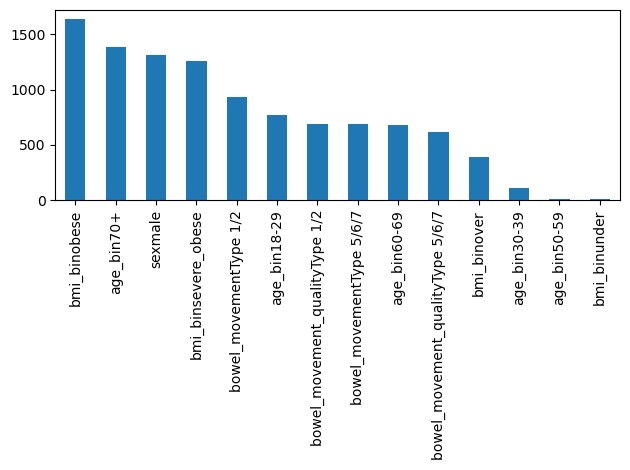

In [ ]:
os.makedirs("figs/ANCOM-BC", exist_ok=True)
sig_counts = sig_counts.drop("(Intercept)", errors="ignore")
sig_counts.plot(kind="bar")
plt.tight_layout()
plt.savefig(
    "figs/sig_counts.png",
    dpi=300,
    bbox_inches="tight"
)

In [29]:
var_map = {
    "age_bin": "Age",
    "bmi_bin": "BMI",
    "bowel_movement": "Bowel movement",
    "bowel_movement_quality": "Bowel movement quality",
    "sex": "Sex"
}

collapsed = (
    (q < 0.05)
    .rename(columns=lambda c: next(
        (v for k, v in var_map.items() if c.startswith(k)), None
    ))
)

collapsed_counts = collapsed.groupby(axis=1, level=0).sum()
collapsed_counts.sum().sort_values(ascending=False)

/tmp/ipykernel_34434/2432758817.py:16: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  collapsed_counts = collapsed.groupby(axis=1, level=0).sum()


BMI               3294
Age               2960
Bowel movement    2928
Sex               1310
dtype: int64

## Running PERMANOVA

In [30]:
# from qiime2.plugins.diversity_lib.methods import bray_curtis

# # Compute Bray-Curtis distance matrix (QIIME2 DistanceMatrix artifact)
# bray_res = bray_curtis(table=table_art)
# bray_dm_art = bray_res.distance_matrix

# # Save distance matrix to disk as TSV
# dm_fp = "bray_curtis_dm.tsv"
# bray_dm_art.export_data(os.getcwd())  # exports into current directory
# os.replace("distance-matrix.tsv", dm_fp)

# print("Saved:", dm_fp)

In [31]:
# factors = ["bowel_movement", "bowel_movement_quality", "age_bin", "bmi_bin", "sex"]

# md_df = md.copy()

# # Keeping only factors I want
# missing = [c for c in factors if c not in md_df.columns]
# if missing:
#     raise ValueError(f"Missing columns in metadata: {missing}")

# # Read distance matrix IDs (header row/col) to align metadata
# dm = pd.read_csv("bray_curtis_dm.tsv", sep="\t", index_col=0)
# dm_ids = dm.index.astype(str)

# # Subset + align metadata to distance matrix IDs
# md_sub = md_df.loc[md_df.index.astype(str).isin(dm_ids), factors].copy()
# md_sub.index = md_sub.index.astype(str)

# # IMPORTANT: remove samples with any NA in the factors (adonis2 requires complete cases)
# md_sub = md_sub.dropna(axis=0, how="any")

# # Re-filter DM to the remaining metadata IDs (same order)
# keep_ids = md_sub.index.tolist()
# dm = dm.loc[keep_ids, keep_ids]

# # Clean factor levels
# for c in factors:
#     md_sub[c] = md_sub[c].astype(str).str.strip()
#     md_sub[c] = md_sub[c].str.replace("/", "_", regex=False)
#     md_sub[c] = md_sub[c].str.replace(" ", "_", regex=False)
#     md_sub[c] = md_sub[c].astype("category")

# # Save both to disk for R
# md_fp = "permanova_metadata.tsv"
# dm_fp = "bray_curtis_dm.tsv"
# md_sub.to_csv(md_fp, sep="\t")
# dm.to_csv(dm_fp, sep="\t")

# print("Saved metadata:", md_fp, "shape:", md_sub.shape)
# print("Saved aligned dm:", dm_fp, "shape:", dm.shape)

In [32]:
# %load_ext rpy2.ipython

In [33]:
# %%R
# library(vegan)

# # Load aligned inputs
# dm <- read.table("bray_curtis_dm.tsv", header=TRUE, row.names=1, sep="\t", check.names=FALSE)
# md <- read.table("permanova_metadata.tsv", header=TRUE, row.names=1, sep="\t", check.names=FALSE)

# # Convert matrix -> dist object
# dm_mat <- as.matrix(dm)
# dm_dist <- as.dist(dm_mat)

# # Make sure columns are factors
# cols <- colnames(md)
# for (c in cols) md[[c]] <- as.factor(md[[c]])

# # Multifactor PERMANOVA (all factors at once)
# set.seed(0)
# res_margin <- adonis2(dm_dist ~ bowel_movement + bowel_movement_quality + age_bin + bmi_bin + sex,
#                       data = md, permutations = 199, by = "margin")

# print("=== Marginal (by=margin) ===")
# print(res_margin)

# # Save results
# write.csv(as.data.frame(res_margin), "adonis2_marginal.csv")
# cat("Saved: adonis2_marginal.csv\n")

## PERMANOVA Results

In [34]:
df = pd.read_csv("/home/nxwang/adonis2_marginal.csv")

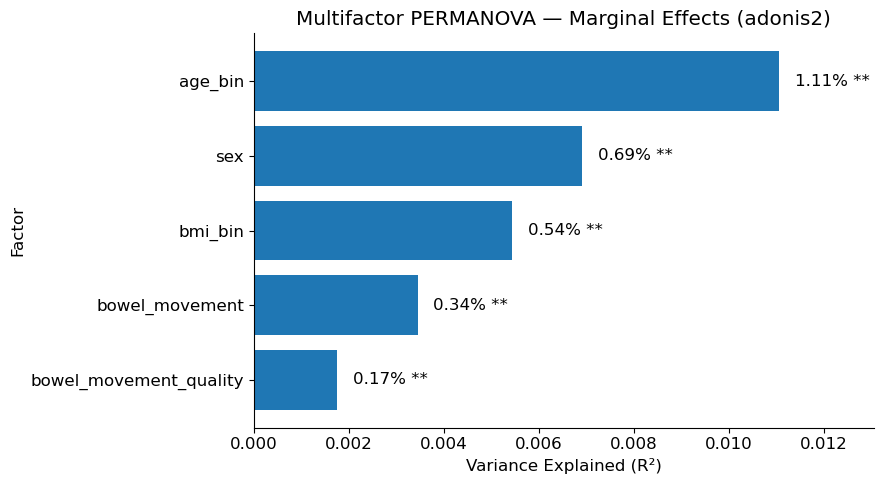

In [ ]:
# Multifactor PERMANOVA (adonis2 by=margin) results plot
# Assumes you already created: adonis2_marginal.csv

import pandas as pd
import matplotlib.pyplot as plt

# Load adonis2 output (from %%R cell)
df = pd.read_csv("adonis2_marginal.csv")

# Keep only factor rows (drop Residual/Total)
df = df[~df["Unnamed: 0"].isin(["Residual", "Total"])].copy()

# Sort so smallest is on bottom
df = df.sort_values("R2", ascending=True)

# Helper: p-value stars
def p_to_stars(p):
    try:
        if pd.isna(p):
            return ""
        if p < 0.001:
            return "***"
        if p < 0.01:
            return "**"
        if p < 0.05:
            return "*"
        return ""
    except Exception:
        return ""

# Plot
plt.rcParams.update({"font.size": 12})
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(df["Unnamed: 0"], df["R2"])

ax.set_title("Multifactor PERMANOVA — Marginal Effects (adonis2)")
ax.set_xlabel("Variance Explained (R²)")
ax.set_ylabel("Factor")

# Annotate each bar w/ percent + stars
xmax = df["R2"].max()
pad = max(0.0003, 0.03 * xmax)  # smart padding for tiny R² values

for bar, r2, p in zip(bars, df["R2"], df["Pr(>F)"]):
    stars = p_to_stars(p)
    label = f"{r2*100:.2f}% {stars}".strip()
    ax.text(
        bar.get_width() + pad,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha="left"
    )

ax.set_xlim(0, xmax + 6 * pad)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figs/ANCOM-BC/permanova_marginal_variance.png", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
# Load PERMANOVA marginal results
perm = pd.read_csv("adonis2_marginal.csv")

# vegan writes rownames into first column sometimes as "Unnamed: 0"
term_col = "Unnamed: 0" if "Unnamed: 0" in perm.columns else perm.columns[0]
perm = perm.rename(columns={term_col: "Term"})

perm = perm[~perm["Term"].isin(["Residual", "Total"])]
perm = perm[["Term", "R2", "F", "Pr(>F)"]].copy()

# Compute DA counts per factor from ANCOM-BC q-values
factors = ["bowel_movement", "bowel_movement_quality", "age_bin", "bmi_bin", "sex"]

da_counts = []
for f in factors:
    coef_cols = [c for c in q.columns if c.startswith(f)]
    if len(coef_cols) == 0:
        da_counts.append(0)
        continue
    # count features significant in ANY level of that factor
    sig_any = (q[coef_cols] < 0.05).any(axis=1)
    da_counts.append(int(sig_any.sum()))

da = pd.DataFrame({"Term": factors, "DA_sig_features": da_counts})

# Merge
summary = perm.merge(da, on="Term", how="left").fillna({"DA_sig_features": 0})
summary


,Term,R2,F,Pr(>F),DA_sig_features
0,bowel_movement,0.003448,5.953207,0.005,1704
1,bowel_movement_quality,0.001749,3.020674,0.005,1091
2,age_bin,0.011063,7.641301,0.005,1734
3,bmi_bin,0.005431,4.688840,0.005,1807
4,sex,0.006916,23.885402,0.005,1310


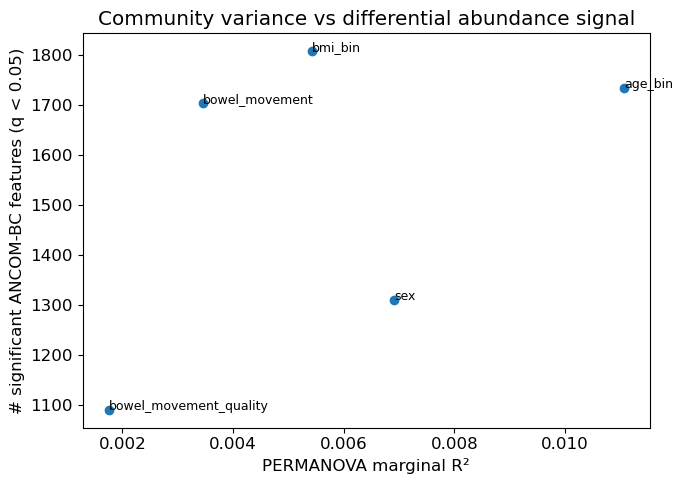

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(summary["R2"], summary["DA_sig_features"])

for _, r in summary.iterrows():
    plt.text(r["R2"], r["DA_sig_features"], r["Term"], fontsize=9)

plt.xlabel("PERMANOVA marginal R²")
plt.ylabel("# significant ANCOM-BC features (q < 0.05)")
plt.title("Community variance vs differential abundance signal")
plt.tight_layout()
plt.savefig(
    "figs/ANCOM-BC/comm_var_vs_da_sig.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Mapping Taxanomy to ANCOM-BC Results

In [38]:
def join_tax_to_ancom(lfc, q, tax, alpha=0.05):

    lfc_long = lfc.stack(dropna=False).rename("lfc").reset_index()
    lfc_long.columns = ["feature_id", "term", "lfc"]

    q_long = q.stack(dropna=False).rename("q").reset_index()
    q_long.columns = ["feature_id", "term", "q"]

    out = (lfc_long.merge(q_long, on=["feature_id","term"])
                  .merge(tax.reset_index(), on="feature_id", how="left"))

    out["lfc"] = pd.to_numeric(out["lfc"], errors="coerce")
    out["q"]   = pd.to_numeric(out["q"], errors="coerce")

    # drop intercept
    out = out[out["term"] != "(Intercept)"]

    sig = out[(out["q"] < alpha) & out["lfc"].notna()].copy()
    sig["abs_lfc"] = sig["lfc"].abs()

    return out, sig

In [39]:
all_hits, sig_hits = join_tax_to_ancom(lfc, q, tax)

/tmp/ipykernel_34434/2788315421.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  lfc_long = lfc.stack(dropna=False).rename("lfc").reset_index()
/tmp/ipykernel_34434/2788315421.py:6: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  q_long = q.stack(dropna=False).rename("q").reset_index()


## ANCOM-BC Results

In [40]:
def collapse_to_genus(sig_df):

    df = sig_df.copy()
    df["genus"] = df["genus"].fillna("Unassigned")

    df = (df.sort_values(["term","genus","abs_lfc"], ascending=[True, True, False])
            .groupby(["term","genus"], as_index=False)
            .head(1))

    return df

sig_genus = collapse_to_genus(sig_hits)

In [41]:
def top_up_down(sig_genus, n=10):

    rows = []

    for term, g in sig_genus.groupby("term"):

        g = g.sort_values("lfc", ascending=False)

        up   = g.head(n)
        down = g.tail(n).sort_values("lfc")

        for _, r in up.iterrows():
            rows.append([term, "UP", r["genus"], r["lfc"], r["q"]])

        for _, r in down.iterrows():
            rows.append([term, "DOWN", r["genus"], r["lfc"], r["q"]])

    return pd.DataFrame(rows, columns=["term","direction","genus","lfc","q"])

report_table = top_up_down(sig_genus, n=10)
report_table.head(20)

,term,direction,genus,lfc,q
0,age_bin18-29,UP,Haemophilus_D,1.116618,5.476402e-09
1,age_bin18-29,UP,Dialister,1.102445,1.416241e-03
2,age_bin18-29,UP,Bifidobacterium,1.095271,6.415482e-05
3,age_bin18-29,UP,Sutterella,0.990209,8.675152e-03
4,age_bin18-29,UP,Veillonella,0.884233,4.060415e-08
5,age_bin18-29,UP,Prevotella,0.755888,3.575373e-02
6,age_bin18-29,UP,Ligilactobacillus,0.745029,3.508165e-10
7,age_bin18-29,UP,Turicibacter,0.692101,8.047821e-07
8,age_bin18-29,UP,Lachnospira,0.676091,1.757598e-04
9,age_bin18-29,UP,Aggregatibacter,0.645651,3.015537e-07


In [42]:
def genus_lfc_matrix(all_hits):

    df = all_hits.copy()

    # fallback label
    df["genus"] = df["genus"].fillna("Unassigned")

    # aggregate LFC across features → genus
    genus_lfc = (
        df.groupby(["genus","term"])["lfc"]
          .mean()              # mean effect size
          .unstack(fill_value=0)
    )

    return genus_lfc

genus_lfc = genus_lfc_matrix(all_hits)

In [43]:
term_groups = {
    "Age": [
        'age_bin18-29','age_bin30-39','age_bin50-59','age_bin60-69','age_bin70+'
    ],
    "BMI": [
        'bmi_binunder','bmi_binover','bmi_binobese','bmi_binsevere_obese'
    ],
    "Bowel movement type": [
        'bowel_movementType 1/2','bowel_movementType 5/6/7'
    ],
    "Bowel movement quality": [
        'bowel_movement_qualityType 1/2','bowel_movement_qualityType 5/6/7'
    ],
    "Sex": ['sexmale']
}

In [ ]:
def plot_group_heatmap(genus_lfc, group_name, terms, top_n=40):
    sub = genus_lfc[terms].copy()

    # pick top genera by max abs LFC within group (so heatmap is readable)
    score = sub.abs().max(axis=1).sort_values(ascending=False)
    keep = score.head(top_n).index
    sub = sub.loc[keep].fillna(0)

    plt.figure(figsize=(1.0 * len(terms) + 4, max(4, 0.25 * len(keep))))
    sns.heatmap(sub, center=0, cmap="coolwarm")
    plt.title(f"{group_name}: Genus log fold change (top {top_n})")
    plt.xlabel("Term / bin")
    plt.ylabel("Genus")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    fname = group_name.lower().replace(" ", "_")
    plt.savefig(
        f"figs/ANCOM-BC/ancombc_{fname}_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

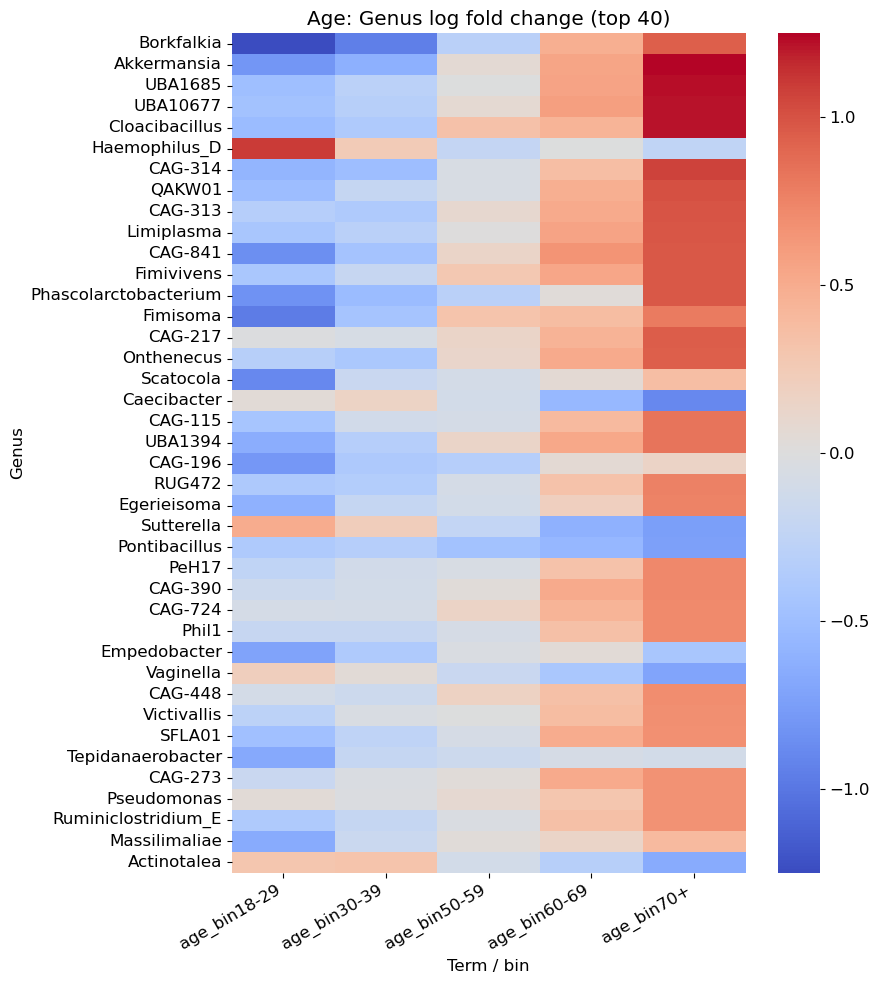

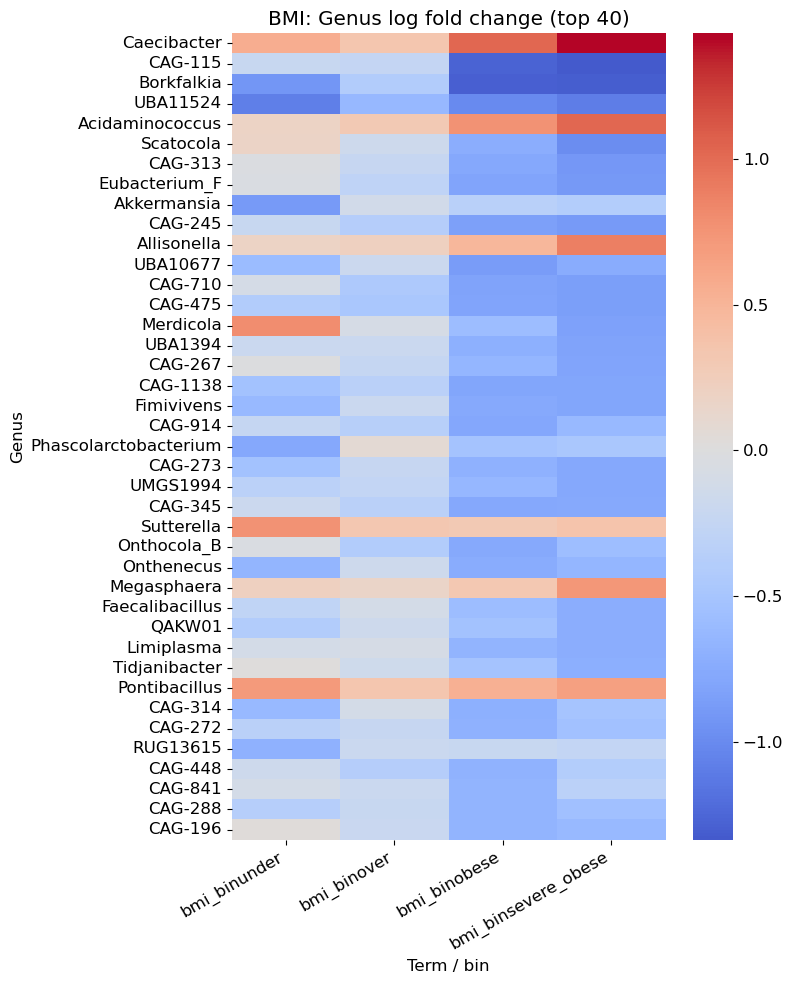

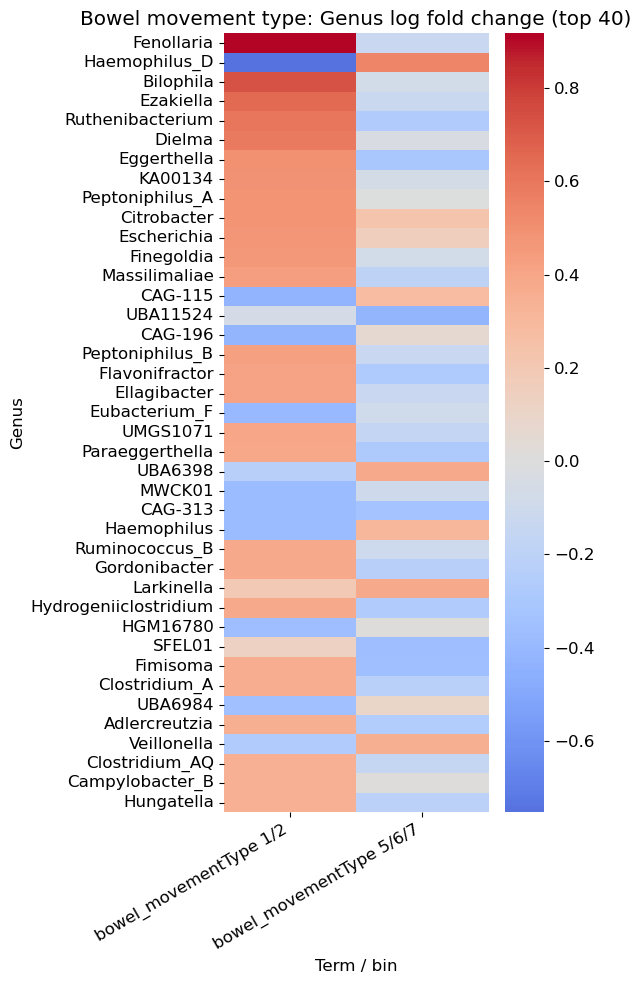

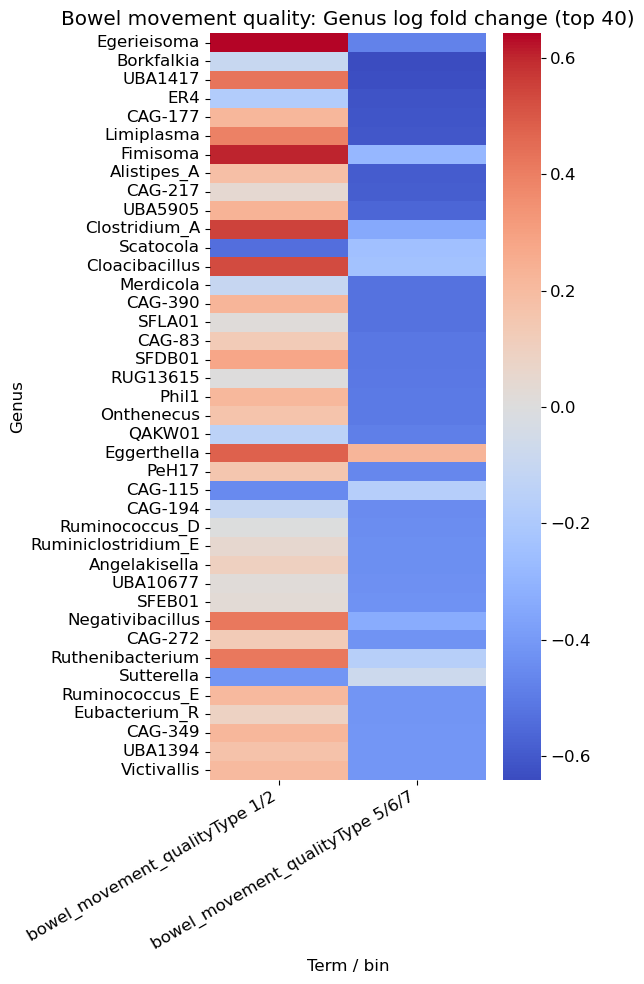

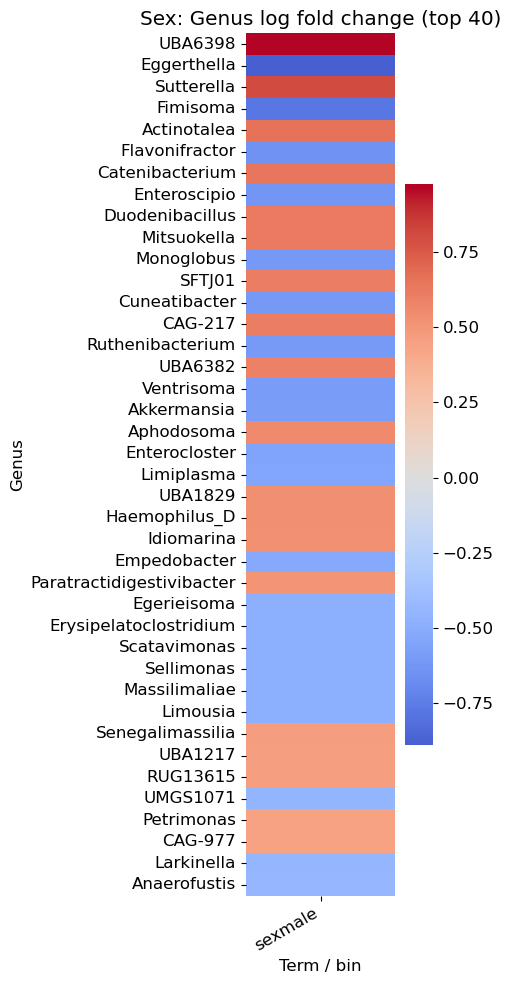

In [45]:
for group_name, terms in term_groups.items():
    plot_group_heatmap(genus_lfc, group_name, terms, top_n=40)

In [ ]:
def plot_group_trends(genus_lfc, group_name, terms, top_n=15):
    sub = genus_lfc[terms].copy()

    score = sub.abs().max(axis=1).sort_values(ascending=False)
    keep = score.head(top_n).index
    sub = sub.loc[keep].fillna(0)

    plt.figure(figsize=(1.0 * len(terms) + 4, max(4, 0.35 * len(keep))))
    for genus in sub.index:
        plt.plot(terms, sub.loc[genus].values, marker="o", linewidth=1)

    plt.axhline(0, linewidth=1)
    plt.title(f"{group_name}: Genus LFC across bins (top {top_n})")
    plt.xlabel("Term / bin")
    plt.ylabel("Log fold change")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    fname = group_name.lower().replace(" ", "_")
    plt.savefig(
        f"figs/ANCOM-BC/ancombc_{fname}_trends.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

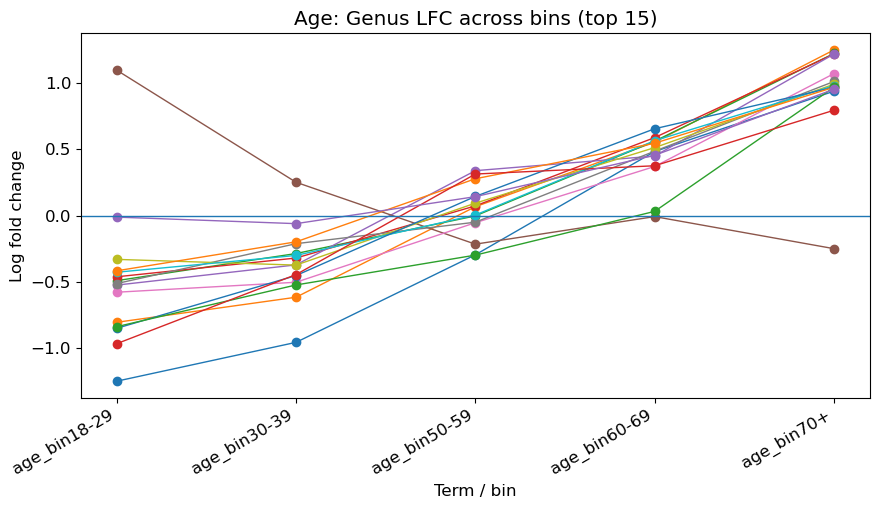

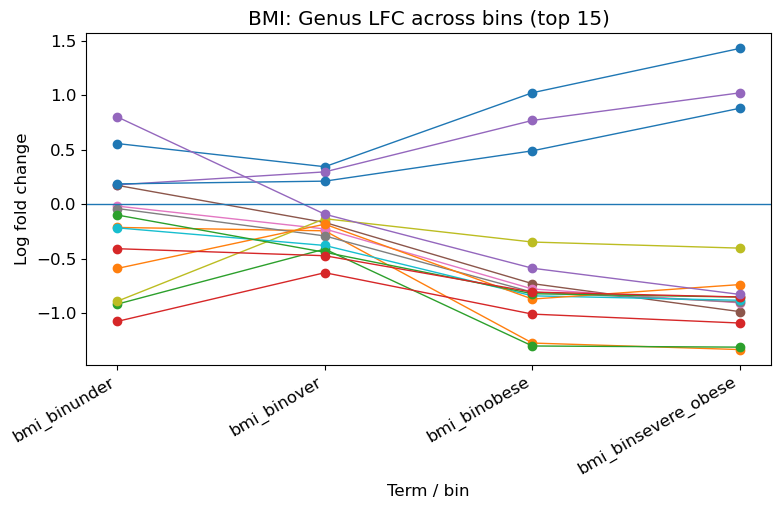

In [47]:
plot_group_trends(genus_lfc, "Age", term_groups["Age"], top_n=15)
plot_group_trends(genus_lfc, "BMI", term_groups["BMI"], top_n=15)


In [ ]:
def plot_group_barh(genus_lfc, group_name, terms, top_n=20):
    sub = genus_lfc[terms].copy()

    score = sub.abs().max(axis=1).sort_values(ascending=False)
    keep = score.head(top_n).index
    sub = sub.loc[keep].fillna(0)

    ax = sub.plot(kind="barh", figsize=(1.3 * len(terms) + 6, max(4, 0.35 * len(keep))))
    ax.axvline(0, linewidth=1)
    ax.set_title(f"{group_name}: Genus LFC (top {top_n})")
    ax.set_xlabel("Log fold change")
    ax.set_ylabel("Genus")
    plt.tight_layout()
    fname = group_name.lower().replace(" ", "_")
    plt.savefig(
        f"figs/ANCOM-BC/ancombc_{fname}_barh.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

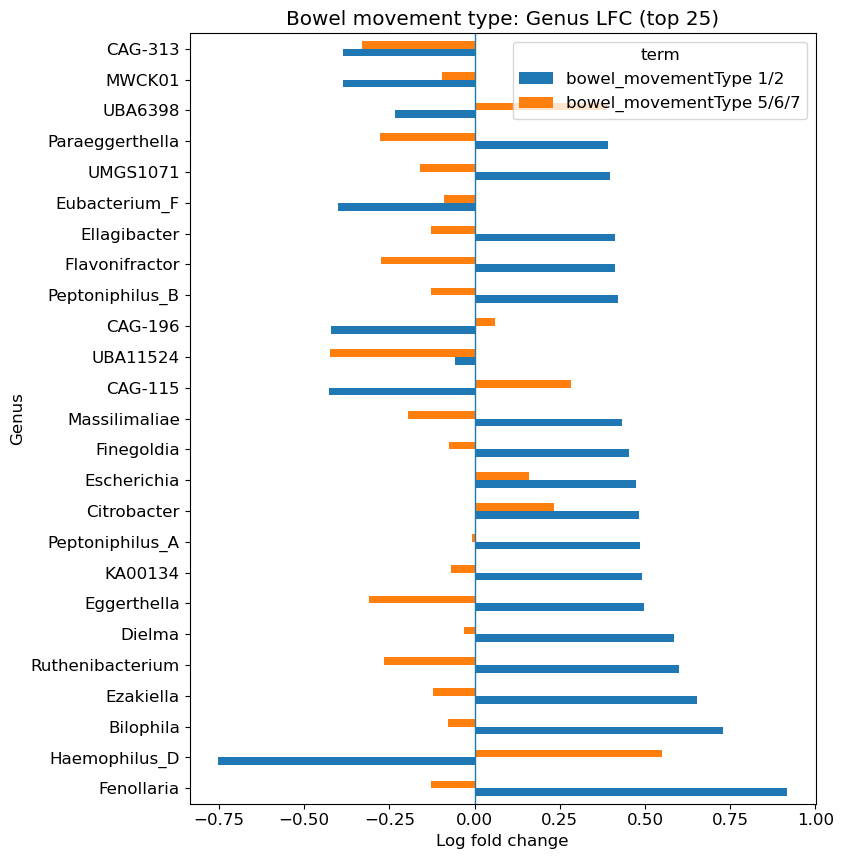

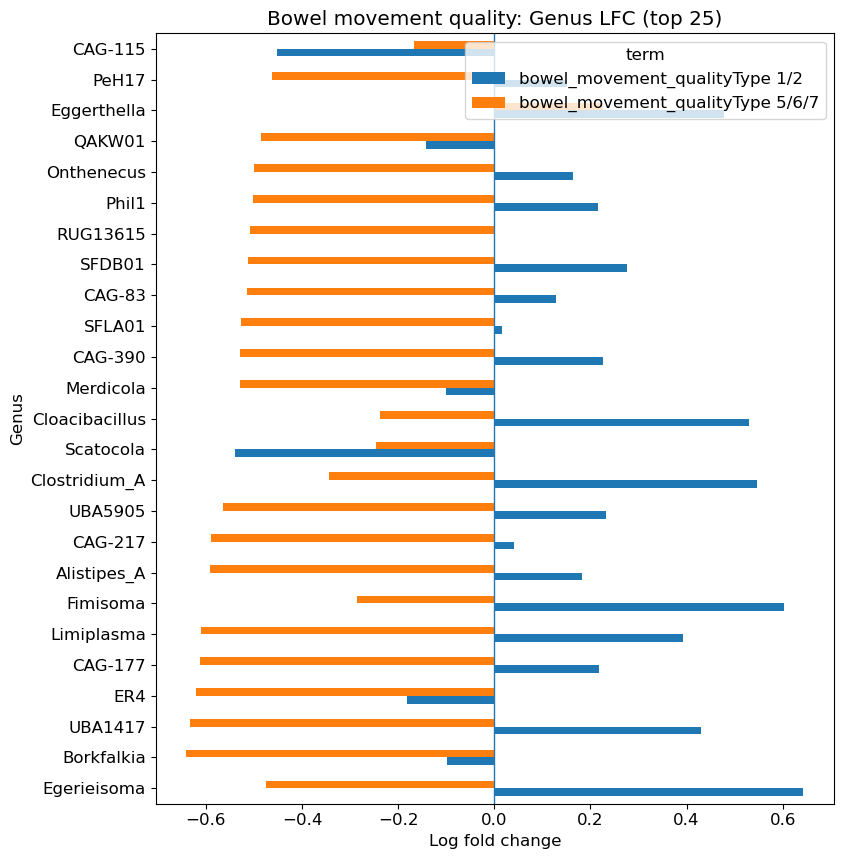

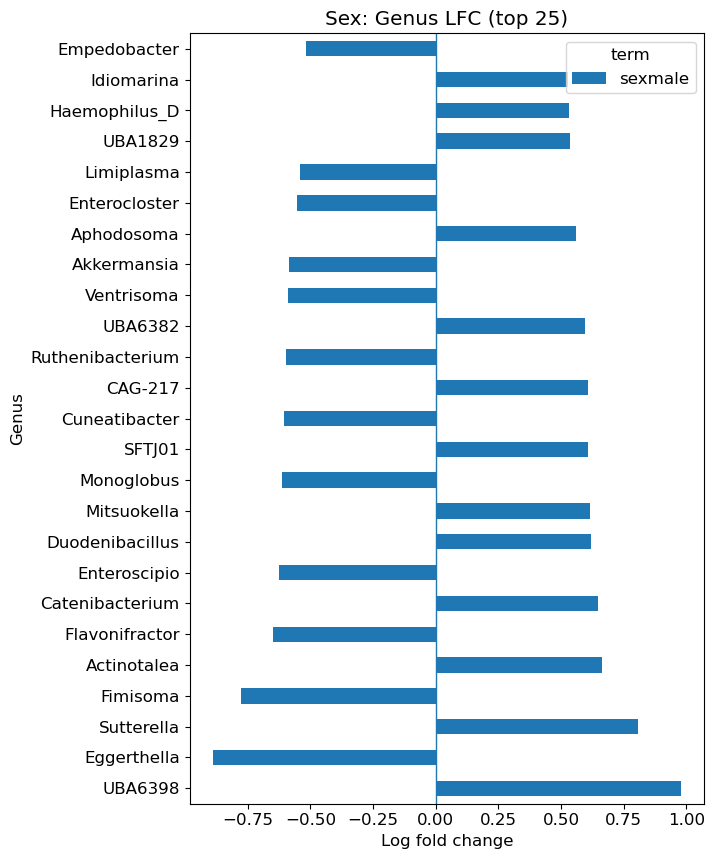

In [49]:
plot_group_barh(genus_lfc, "Bowel movement type", term_groups["Bowel movement type"], top_n=25)
plot_group_barh(genus_lfc, "Bowel movement quality", term_groups["Bowel movement quality"], top_n=25)
plot_group_barh(genus_lfc, "Sex", term_groups["Sex"], top_n=25)

In [50]:
def plot_global_heatmap(genus_lfc, top_n=50):

    score = genus_lfc.abs().max(axis=1).sort_values(ascending=False)
    keep = score.head(top_n).index

    sub = genus_lfc.loc[keep].fillna(0)

    plt.figure(figsize=(1.2 * sub.shape[1] + 4, max(4, 0.25 * top_n)))
    sns.heatmap(sub, center=0, cmap="coolwarm")
    plt.title("ANCOM-BC genus log fold change across all covariates")
    plt.xlabel("Covariate / bin")
    plt.ylabel("Genus")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


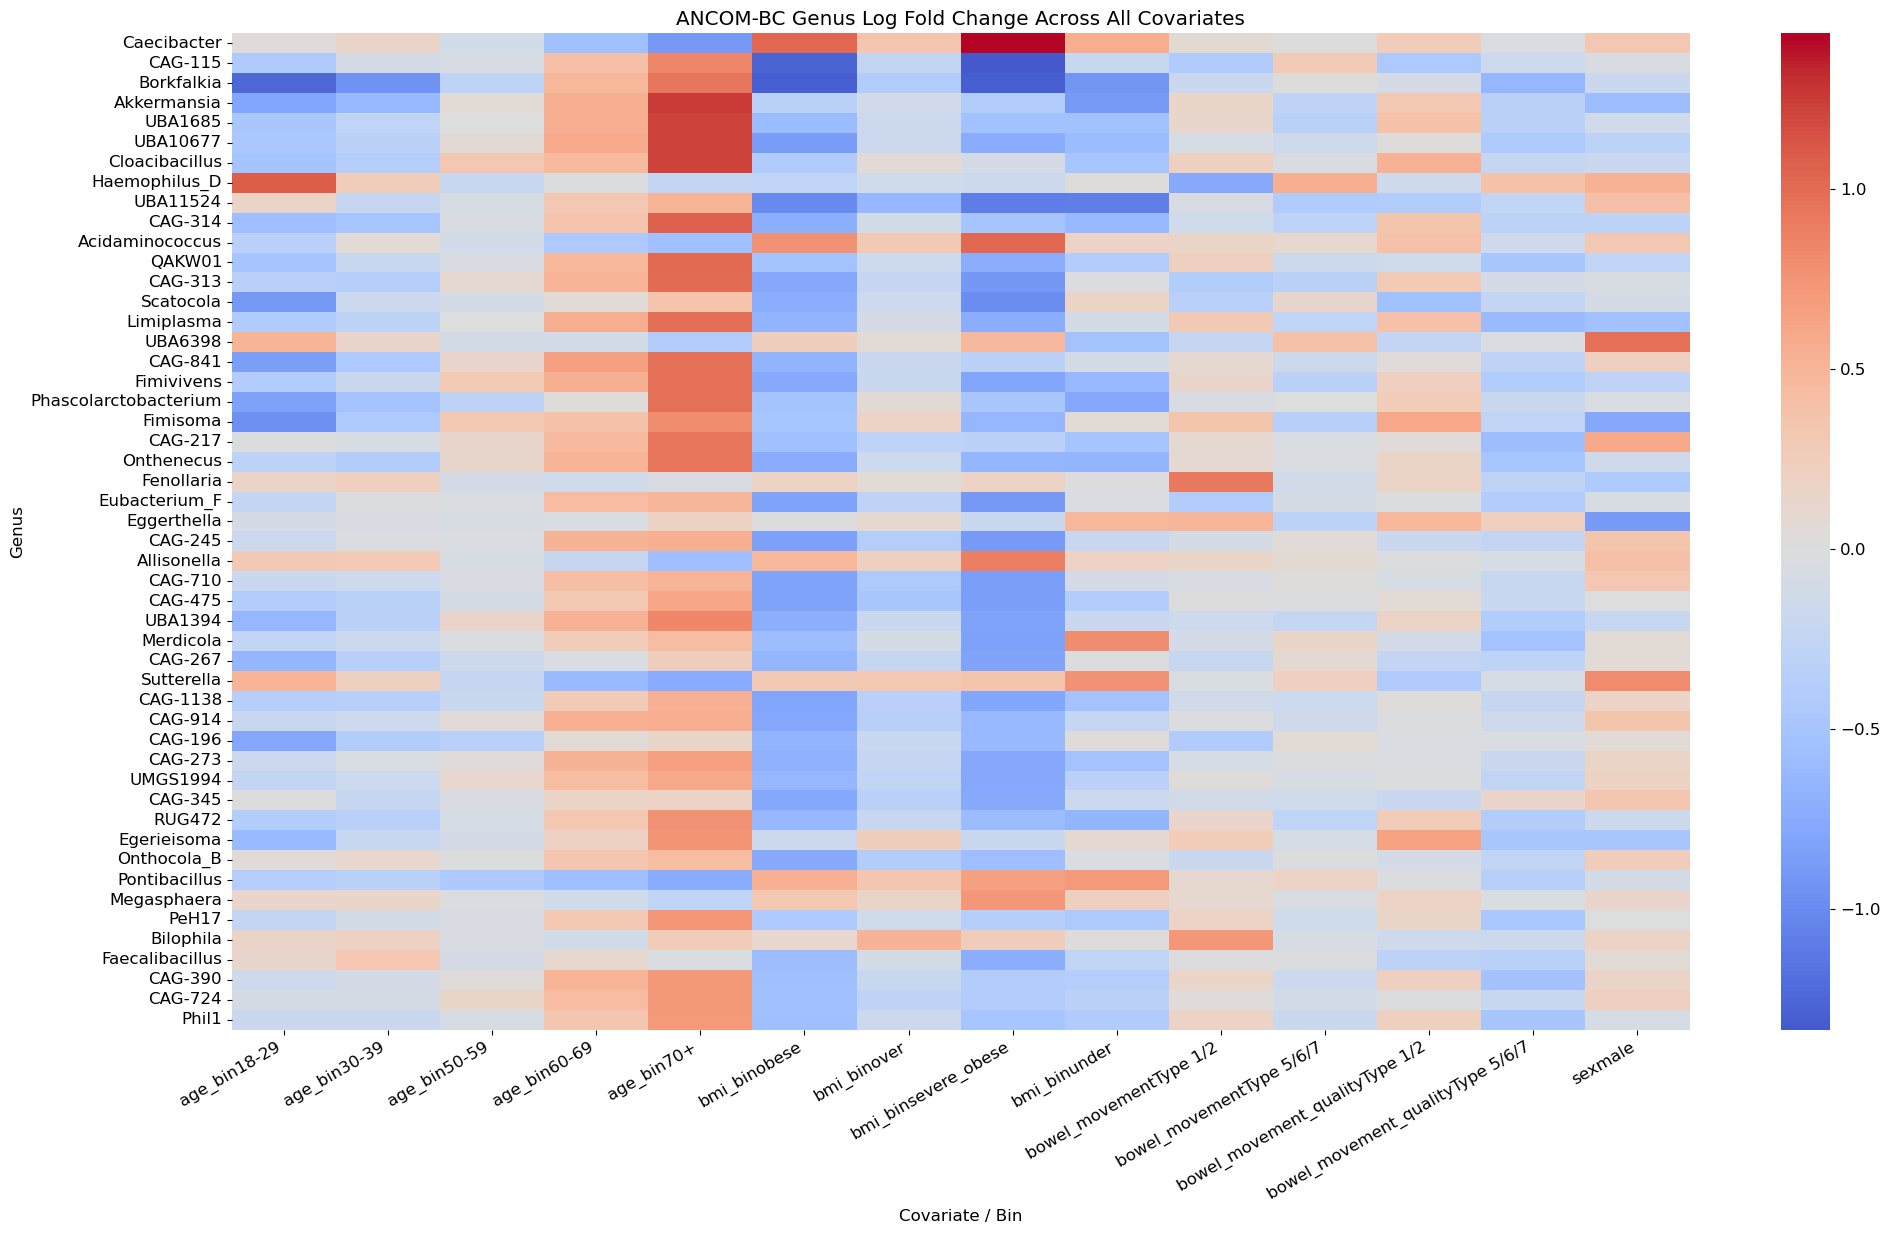

In [ ]:
top_n = 50

# rank genera by strongest absolute LFC across all terms
score = genus_lfc.abs().max(axis=1).sort_values(ascending=False)
keep = score.head(top_n).index

# subset + fill missing
sub = genus_lfc.loc[keep].fillna(0)

# plot
plt.figure(figsize=(1.2 * sub.shape[1] + 4, max(4, 0.25 * top_n)))
sns.heatmap(sub, center=0, cmap="coolwarm")

plt.title("ANCOM-BC Genus Log Fold Change Across All Covariates")
plt.xlabel("Covariate / Bin")
plt.ylabel("Genus")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(
    "figs/ANCOM-BC/ancombc_genus_lfc_all_covariates.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

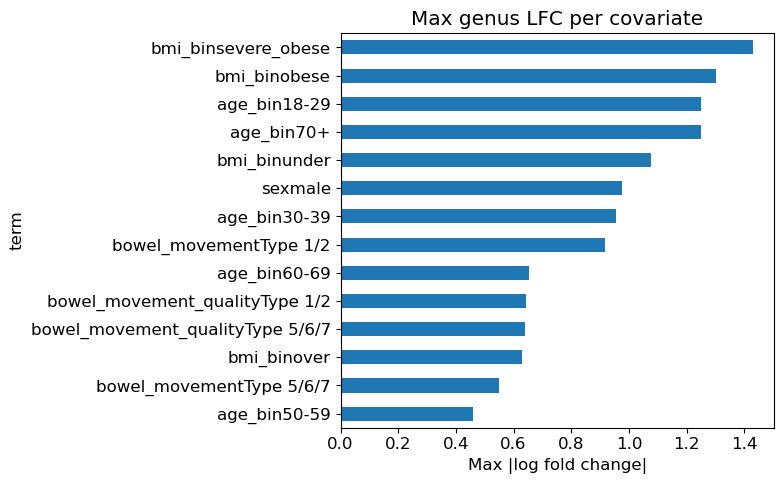

In [ ]:
vol = genus_lfc.abs().max(axis=0).sort_values()

vol.plot(kind="barh", figsize=(8,5))
plt.title("Max genus LFC per covariate")
plt.xlabel("Max |log fold change|")

plt.tight_layout()

plt.savefig(
    f"figs/ANCOM-BC/ancombc_max_genus_lfc_per_covariate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()